# Setup

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Check for CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda:3')  # Use GPU X if available
else:
    device = torch.device('cpu')     # Fallback to CPU if no GPU is available
    
print(device)


cuda:3


# Read data

In [3]:
folder_path = '/raid/sepideh/Project_MCL/1D-AEMpy-UW-metabolism-BM'
file_path = os.path.join(folder_path, "all_data_lake_modeling_process_based.csv")

df = pd.read_csv(file_path)

In [4]:
all_columns= ['depth', 
             'day_of_year_list', 'time_of_day_list', # time features
            
            'temp_initial00', 'do_bc02', 'docl_bc02', 'docr_bc02', 'pocl_bc02', 'pocr_bc02', 
            'area_input', 'volume_input',

            # output
            'do_pd03', 'docr_pd03','docl_pd03','pocr_pd03','pocl_pd03', 'docr_resp_pd03', 'docl_resp_pd03','poc_resp_pd03',
            ]
df_m = df[all_columns]
df_m

,depth,day_of_year_list,time_of_day_list,temp_initial00,do_bc02,docl_bc02,docr_bc02,pocl_bc02,pocr_bc02,area_input,volume_input,do_pd03,docr_pd03,docl_pd03,pocr_pd03,pocl_pd03,docr_resp_pd03,docl_resp_pd03,poc_resp_pd03
0,0.0,138,18,15.800000,2.230776e+08,1.998307e+07,1.000912e+08,1.019349e+07,9.963798e+06,38887500.0,19925000.0,2.227493e+08,1.000826e+08,1.995459e+07,9.921259e+06,1.014997e+07,0.002054,0.034227,0.102682
1,1.0,138,18,15.600000,2.204061e+08,1.899623e+07,9.445548e+07,9.614867e+06,9.482548e+06,36962500.0,18962500.0,2.201040e+08,9.444764e+07,1.896995e+07,9.443247e+06,9.575018e+06,0.001994,0.033225,0.099675
2,2.0,138,18,15.400000,2.099567e+08,1.801990e+07,8.890113e+07,9.078311e+06,9.001298e+06,35500000.0,18000000.0,2.096759e+08,8.889388e+07,1.799542e+07,8.964666e+06,9.041366e+06,0.001957,0.032623,0.097868
3,3.0,138,18,15.200000,2.057773e+08,1.751207e+07,8.569257e+07,8.796989e+06,8.751298e+06,34500000.0,17500000.0,2.055109e+08,8.568574e+07,1.748882e+07,8.716487e+06,8.761996e+06,0.001913,0.031886,0.095657
4,4.0,138,18,14.800000,2.015404e+08,1.700743e+07,8.252626e+07,8.528432e+06,8.501298e+06,33525000.0,17000000.0,2.012874e+08,8.251981e+07,1.698532e+07,8.468185e+06,8.495214e+06,0.001873,0.031221,0.093662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189995,45.0,136,17,7.536653,1.366915e+07,7.251384e+05,5.789239e+06,2.186816e+06,4.567812e+04,2075000.0,1275000.0,1.365336e+07,5.788974e+06,7.245855e+05,4.557371e+04,2.181818e+06,0.001098,0.018306,0.054919
2189996,46.0,136,17,7.532475,8.411592e+06,4.550910e+05,3.632755e+06,1.849564e+06,3.863856e+04,1225000.0,800000.0,8.398730e+06,3.632589e+06,4.547444e+05,3.855036e+04,1.845341e+06,0.001097,0.018284,0.054853
2189997,47.0,136,17,7.486889,4.164276e+06,2.421641e+05,1.931016e+06,1.522720e+06,3.181220e+04,475000.0,425000.0,4.154155e+06,1.930929e+06,2.419809e+05,3.174008e+04,1.519268e+06,0.001090,0.018159,0.054477
2189998,48.0,136,17,7.060261,2.252801e+05,2.893348e+04,2.283542e+05,1.215545e+06,2.539525e+04,75000.0,50000.0,2.183402e+05,2.283447e+05,2.891345e+04,2.534255e+04,1.213022e+06,0.000997,0.016619,0.049858


# Preprocessing

In [5]:
# Specify input and output columns

input_binary = ['ice_final06'] # remain unchanged

output_columns = ['do_pd03', 'docr_pd03','docl_pd03','pocr_pd03','pocl_pd03', 'docr_resp_pd03', 'docl_resp_pd03','poc_resp_pd03']

features_to_normalize = list(set(all_columns) - set(input_binary))
features_to_normalize



['temp_initial00',
 'pocl_pd03',
 'docl_resp_pd03',
 'volume_input',
 'docr_bc02',
 'docr_resp_pd03',
 'docl_bc02',
 'docr_pd03',
 'pocr_pd03',
 'pocr_bc02',
 'depth',
 'do_pd03',
 'pocl_bc02',
 'area_input',
 'day_of_year_list',
 'docl_pd03',
 'do_bc02',
 'time_of_day_list',
 'poc_resp_pd03']

### Split data train-val-test

In [6]:

training_frac = 0.60
val_frac = 0.2

depth_steps = 50
number_days = len(df_m)//depth_steps

# Calculate number of observations for each set
n_obs_train = int(number_days * training_frac) * depth_steps
n_obs_val = int(number_days * val_frac) * depth_steps

print(f"Number of days total: {number_days}")


Number of days total: 43800


In [7]:
train_df = df_m.iloc[:n_obs_train]
val_df = df_m.iloc[n_obs_train:n_obs_train + n_obs_val]
test_df = df_m.iloc[n_obs_train + n_obs_val:]

print(f"Number of training points: {train_df.shape}")
print(f"Number of validation points: {val_df.shape}")
print(f"Number of test points: {test_df.shape}")

Number of training points: (1314000, 19)
Number of validation points: (438000, 19)
Number of test points: (438000, 19)


### Normalize other features

In [8]:
features_to_normalize

['temp_initial00',
 'pocl_pd03',
 'docl_resp_pd03',
 'volume_input',
 'docr_bc02',
 'docr_resp_pd03',
 'docl_bc02',
 'docr_pd03',
 'pocr_pd03',
 'pocr_bc02',
 'depth',
 'do_pd03',
 'pocl_bc02',
 'area_input',
 'day_of_year_list',
 'docl_pd03',
 'do_bc02',
 'time_of_day_list',
 'poc_resp_pd03']

In [9]:
train_features_to_normalize = train_df[features_to_normalize].values
val_data_features_to_normalize = val_df[features_to_normalize].values
test_features_to_normalize = test_df[features_to_normalize].values

In [10]:
# Initialize StandardScaler and fit on training features
scaler = StandardScaler()
scaler.fit(train_features_to_normalize)

# Transform training, test, and validation features using the fitted scaler
train_df[features_to_normalize] = scaler.transform(train_features_to_normalize)
val_df[features_to_normalize] = scaler.transform(val_data_features_to_normalize)
test_df[features_to_normalize] = scaler.transform(test_features_to_normalize)

In [11]:
train_df

,depth,day_of_year_list,time_of_day_list,temp_initial00,do_bc02,docl_bc02,docr_bc02,pocl_bc02,pocr_bc02,area_input,volume_input,do_pd03,docr_pd03,docl_pd03,pocr_pd03,pocl_pd03,docr_resp_pd03,docl_resp_pd03,poc_resp_pd03
0,-1.697749,-0.428508,0.939010,1.392066,1.843013,4.389883,2.424160,0.923367,20.604998,1.819655,1.869146,1.840076,2.424040,4.389380,20.552955,0.922646,1.401871,1.401871,1.401871
1,-1.628453,-0.428508,0.939010,1.359058,1.805363,4.099866,2.182724,0.821412,19.591316,1.639226,1.689047,1.802780,2.182619,4.099583,19.544289,0.820897,1.316096,1.316096,1.316096
2,-1.559158,-0.428508,0.939010,1.326050,1.658102,3.812939,1.944772,0.726870,18.577634,1.502148,1.508948,1.655755,1.944678,3.812763,18.534424,0.726456,1.264551,1.264551,1.264551
3,-1.489862,-0.428508,0.939010,1.293042,1.599202,3.663696,1.807315,0.677301,18.051046,1.408419,1.415390,1.597034,1.807231,3.663661,18.010734,0.677016,1.201466,1.201466,1.201466
4,-1.420566,-0.428508,0.939010,1.227026,1.539492,3.515390,1.671668,0.629981,17.524458,1.317033,1.321832,1.537487,1.671592,3.515473,17.486786,0.629804,1.144565,1.144565,1.144565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,1.420566,-0.437986,0.794547,-0.004001,-1.120614,-1.297487,-1.611394,-0.503341,-0.263583,-1.630744,-1.620563,-1.120394,-1.611409,-1.298132,-0.263513,-0.503414,0.011009,0.011009,0.011009
1313996,1.489862,-0.437986,0.794547,-0.020397,-1.196445,-1.365560,-1.705322,-0.549780,-0.278504,-1.710414,-1.709443,-1.196223,-1.705339,-1.366254,-0.278424,-0.549942,-0.006867,-0.006867,-0.006867
1313997,1.559158,-0.437986,0.794547,-0.066335,-1.256000,-1.419052,-1.779450,-0.596337,-0.293462,-1.780710,-1.779611,-1.255768,-1.779468,-1.419783,-0.293369,-0.596578,-0.057311,-0.057311,-0.057311
1313998,1.628453,-0.437986,0.794547,-0.219977,-1.299142,-1.474722,-1.853819,-0.641245,-0.307891,-1.818202,-1.849780,-1.298879,-1.853839,-1.475494,-0.307764,-0.641494,-0.324414,-0.324414,-0.324414


# Training 

In [12]:
# the deep neural network
class MLP(torch.nn.Module):
    def __init__(self, layers, activation="relu", init="xavier"):
        super(MLP, self).__init__()
        
        # parameters
        self.depth = len(layers) - 1
        
        if activation == "relu":
            self.activation = torch.nn.ReLU()
        elif activation == "tanh":
            self.activation = torch.nn.Tanh()
        elif activation == "gelu":
            self.activation = torch.nn.GELU()
        else:
            raise ValueError("Unspecified activation type")
        
        
        layer_list = list()
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation))
            
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        
        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

        if init=="xavier":
            self.xavier_init_weights()
        elif init=="kaiming":
            self.kaiming_init_weights()
    
    def xavier_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Xavier Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.xavier_uniform_(m.weight)
                    m.bias.data.fill_(0.0)

    def kaiming_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Kaiming Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.kaiming_uniform_(m.weight)
                    m.bias.data.fill_(0.0)
                        
    def forward(self, x):
        out = self.layers(x)
        return out
    
class DataGenerator(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
    def __len__(self):
        return len(self.X)

In [13]:
input_columns = [column for column in train_df.columns if column not in output_columns]

input_column_ix = [train_df.columns.get_loc(column) for column in input_columns]
output_column_ix = [train_df.columns.get_loc(column) for column in output_columns]

train_array = train_df.values
test_array = test_df.values
val_array = val_df.values

# Use the column indices to select the input and output data
X_train, X_test, X_val = train_array[:,input_column_ix], test_array[:,input_column_ix], val_array[:, input_column_ix]
y_train, y_test, y_val = train_array[:,output_column_ix], test_array[:,output_column_ix], val_array[:, output_column_ix]


In [14]:
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")


X_train: (1314000, 11), X_val: (438000, 11), X_test: (438000, 11)
y_train: (1314000, 8), y_val: (438000, 8), y_test: (438000, 8)


In [15]:
# Create data set
batch_size = 1024
train_dataset = DataGenerator(X_train, y_train)
val_dataset = DataGenerator(X_val, y_val)
test_dataset = DataGenerator(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)

In [16]:
layers = [X_train.shape[-1], 32, 32, y_train.shape[-1]]

model = MLP(layers, activation="gelu").to(device)

Initializing Network with Xavier Initialization..


In [17]:
lr = 1e-3
decay_rate = 0.1
decay_steps = 500
    
optimizer = torch.optim.Adam(model.parameters(), lr=lr, 
                         betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_steps, gamma=decay_rate)

criterion = torch.nn.MSELoss()

In [18]:
print(model)


MLP(
  (activation): GELU(approximate='none')
  (layers): Sequential(
    (layer_0): Linear(in_features=11, out_features=32, bias=True)
    (activation_0): GELU(approximate='none')
    (layer_1): Linear(in_features=32, out_features=32, bias=True)
    (activation_1): GELU(approximate='none')
    (layer_2): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [19]:
n_epochs = 100

train_loss = []
val_loss = []
for it in tqdm(range(n_epochs)):
    loss_epoch = 0
    model.train()
    for x, y in iter(train_loader):
        x, y = x.to(device).float(), y.to(device).float()
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach().item()
    lr_scheduler.step()
    
    if it % 1 == 0:
        train_loss.append(loss_epoch/len(train_loader))
        model.eval()
        val_loss_epoch = 0
        for x, y in iter(val_loader):
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            loss = criterion(pred, y)
            val_loss_epoch += loss.detach().item()
        val_loss.append(val_loss_epoch/len(val_loader))
        print(f"Epoch : {it}, Train_loss: {train_loss[-1]}, Val_loss: {val_loss[-1]}")
    

  1%|          | 1/100 [00:15<25:31, 15.47s/it]

Epoch : 0, Train_loss: 0.06096749565915155, Val_loss: 0.01408092228741446


  2%|▏         | 2/100 [00:31<25:50, 15.82s/it]

Epoch : 1, Train_loss: 0.012453300004383995, Val_loss: 0.01123115901125891


  3%|▎         | 3/100 [00:47<25:39, 15.87s/it]

...

Epoch : 97, Train_loss: 0.0010662691851637566, Val_loss: 0.0008251860980695183


 99%|█████████▉| 99/100 [27:17<00:15, 15.90s/it]

Epoch : 98, Train_loss: 0.001043095437777548, Val_loss: 0.0016597178641562002


100%|██████████| 100/100 [27:33<00:00, 16.54s/it]

Epoch : 99, Train_loss: 0.0010572418307042695, Val_loss: 0.000888960319928195


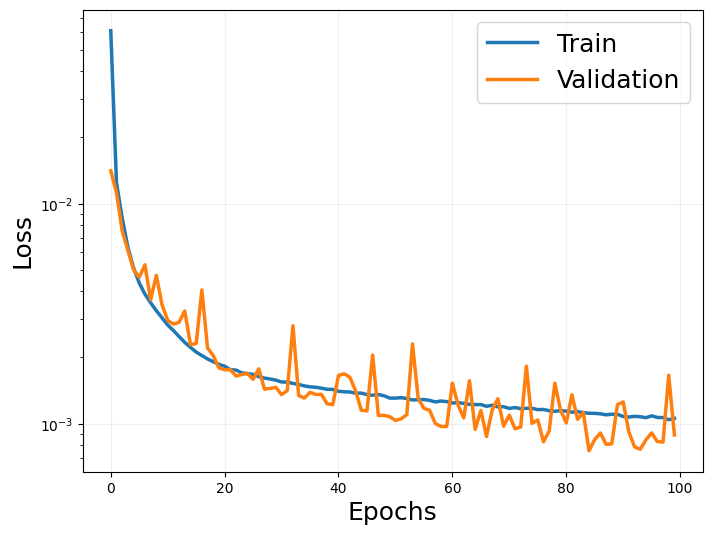

In [20]:
plt.figure(figsize=(8,6))
plt.plot(train_loss, label="Train", linewidth=2.5)
plt.plot(val_loss, label="Validation", linewidth=2.5)
plt.grid("on", alpha=0.2)
plt.legend(fontsize=18)
plt.yscale("log")
plt.xlabel("Epochs", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.show()

# Evaluating results

In [21]:
def rmse(true, pred):
    return (((true - pred) ** 2).mean() ** 0.5).detach().cpu().numpy()

def l2_error(true, pred):
    return np.linalg.norm(pred.detach().cpu().numpy() - true.detach().cpu().numpy()) / np.linalg.norm(true.detach().cpu().numpy())

def compute_metrics(model, loader, output_columns):
    model.eval()
    y_ = []
    pred_ = []
    preds = []
    ys = []
    for x, y in iter(loader):
        x, y = x.to(device).float(), y.to(device).float()
        pred = model(x)
        
        preds.append(pred)
        ys.append(y)

    ys = torch.cat(ys, dim=0) 
    preds = torch.cat(preds, dim=0)
    
    # Compute RMSE and L2 error for each feature
    rmse_values = []
    l2_error_values = []
    
    for i in range(ys.shape[1]):  # Iterate over each feature
        rmse_temp = rmse(ys[:, i], preds[:, i])
        l2_error_temp = l2_error(ys[:, i], preds[:, i])
        rmse_values.append(rmse_temp)
        l2_error_values.append(l2_error_temp)
        
        print(f"- Feature {output_columns[i]}:  RMSE: {rmse_temp:.5f}, L2 Error: {l2_error_temp:.5f}")
    
    # Compute overall RMSE across all features and samples
    overall_rmse = rmse(ys.flatten(), preds.flatten())
    print(f"Overall RMSE: {overall_rmse:.5f}")
    
    return rmse_values, l2_error_values, overall_rmse, ys, preds


In [22]:
print("Validation Errors: ")
rmse_val, l2_error_val, overall_rmse_val, val_gt, val_pred = compute_metrics(model, val_loader, output_columns)

Validation Errors: 


- Feature do_pd03:  RMSE: 0.00485, L2 Error: 0.00481
- Feature docr_pd03:  RMSE: 0.00831, L2 Error: 0.00850
- Feature docl_pd03:  RMSE: 0.01105, L2 Error: 0.01323
- Feature pocr_pd03:  RMSE: 0.00495, L2 Error: 0.02303
- Feature pocl_pd03:  RMSE: 0.00633, L2 Error: 0.00774
- Feature docr_resp_pd03:  RMSE: 0.04769, L2 Error: 0.04682
- Feature docl_resp_pd03:  RMSE: 0.04778, L2 Error: 0.04691
- Feature poc_resp_pd03:  RMSE: 0.04771, L2 Error: 0.04684
Overall RMSE: 0.02982


In [23]:
print("Train Errors: ")
rmse_train, l2_error_train, overall_rmse_val, train_gt, train_pred = compute_metrics(model, train_loader, output_columns)

Train Errors: 
- Feature do_pd03:  RMSE: 0.00493, L2 Error: 0.00493
- Feature docr_pd03:  RMSE: 0.00789, L2 Error: 0.00789
- Feature docl_pd03:  RMSE: 0.00936, L2 Error: 0.00936
- Feature pocr_pd03:  RMSE: 0.00572, L2 Error: 0.00572
- Feature pocl_pd03:  RMSE: 0.00675, L2 Error: 0.00675
- Feature docr_resp_pd03:  RMSE: 0.05060, L2 Error: 0.05060
- Feature docl_resp_pd03:  RMSE: 0.05056, L2 Error: 0.05056
- Feature poc_resp_pd03:  RMSE: 0.05057, L2 Error: 0.05057
Overall RMSE: 0.03148


In [24]:
print("Test Errors: ")
rmse_test, l2_error_test, overall_rmse_val, test_gt, test_pred = compute_metrics(model, test_loader, output_columns)

Test Errors: 
- Feature do_pd03:  RMSE: 0.00449, L2 Error: 0.00448
- Feature docr_pd03:  RMSE: 0.00777, L2 Error: 0.00796
- Feature docl_pd03:  RMSE: 0.01063, L2 Error: 0.01262
- Feature pocr_pd03:  RMSE: 0.00460, L2 Error: 0.02188
- Feature pocl_pd03:  RMSE: 0.00608, L2 Error: 0.00732
- Feature docr_resp_pd03:  RMSE: 0.05449, L2 Error: 0.05692
- Feature docl_resp_pd03:  RMSE: 0.05460, L2 Error: 0.05703
- Feature poc_resp_pd03:  RMSE: 0.05452, L2 Error: 0.05695
Overall RMSE: 0.03387


# Visualizing result

In [25]:
def prepare_heatmap_data(data, df_main):
    # Create a DataFrame for visualization with depth and time as multi-index
    df = pd.DataFrame(data, columns=['predicted_value'])
    df['depth'] = df_main.reset_index(drop=True)['depth']
    df['datetime'] = df_main.reset_index(drop=True)['datetime'] 
    # Pivot to create a depth vs. time structure suitable for heatmap
    heatmap_data = df.pivot_table(index='depth', columns='datetime', values='predicted_value', aggfunc='mean')
    return heatmap_data

In [26]:
for i in range(test_gt.shape[1]):
    # Prepare the data to plot heatmaps
    test_real_data = prepare_heatmap_data(test_gt.detach().cpu().numpy()[:,i], test_df_unnormalized)
    test_pred_data = prepare_heatmap_data(test_pred.detach().cpu().numpy()[:,i], test_df_unnormalized)
    difference_data = test_real_data - test_pred_data

    # Data for plotting
    heatmap_data = [
        (test_real_data, f'Test Real Values of {output_columns[i]}', 'seismic', 'Test Real Values'),
        (test_pred_data, f'Test Predicted Values of {output_columns[i]}', 'seismic', 'Test Predicted Values'),
        (difference_data, f'Difference Between Real and Predicted {output_columns[i]}', 'seismic', 'Difference (Real - Predicted)')
    ]

    # Plot heatmaps
    fig, axs = plt.subplots(len(heatmap_data), 1, figsize=(15, 15))

    for ax, (data, title, cmap, cbar_label) in zip(axs, heatmap_data):
        sns.heatmap(data, cmap=cmap, ax=ax, cbar_kws={'label': cbar_label}, center=0)
        ax.set_title(title)
        ax.set_xlabel('Time')
        ax.set_ylabel('Depth')

    plt.tight_layout()
    plt.show()
    

NameError: name 'test_df_unnormalized' is not defined

# Saving Model

In [27]:
PATH = f"../saved_models/pretrain/m3.pth"
torch.save(model.state_dict(), PATH)